# Master's Thesis Notebook

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026


# test4b exposure source

Notebook equivalent of `tests/4_earth/test4b_exposure_source.py`. The original Python test module remains the source of truth; this notebook imports it and runs each numerical test and diagnostic plot in its own cell for interactive inspection.

The notebook uses the shared TPeanuts output-root convention defined in section `2. Paths`. Generated `earth` test artifacts and figures are redirected to the notebook-specific `OUTPUT_DIR` under `OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM`.


## 1. Libraries and test module

This section locates the repository, imports the original `earth` test module, and reloads it so source changes are reflected when the notebook is rerun. The expected result is that the module imports without errors. Possible problems include running the notebook from outside the repository tree or missing import paths for the editable package.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import sys
import traceback
from pathlib import Path

import matplotlib.pyplot as plt


from tpeanuts.util.notebooks import find_repo_root
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

NOTEBOOK_STEM = "test4b_exposure_source"
TEST_MODULE_PATH = PACKAGE_DIR / "notebooks" / "tests" / "4_earth" / f"{NOTEBOOK_STEM}.py"
TEST_MODULE_NAME = f"notebook_tests_{TEST_MODULE_PATH.parent.name.replace('.', '_')}_{NOTEBOOK_STEM}"
if not TEST_MODULE_PATH.exists():
    raise FileNotFoundError(f"Could not find local test module: {TEST_MODULE_PATH}")
spec = importlib.util.spec_from_file_location(TEST_MODULE_NAME, TEST_MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load test module spec from {TEST_MODULE_PATH}")
TEST_MODULE = importlib.util.module_from_spec(spec)
sys.modules[TEST_MODULE_NAME] = TEST_MODULE
spec.loader.exec_module(TEST_MODULE)
print("Loaded local test module:", TEST_MODULE_PATH)

from tpeanuts.util.notebooks import build_notebook_test_runner


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Loaded local test module: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\4_earth\test4b_exposure_source.py


## 2. Paths

All outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. This notebook writes `earth` test figures and generated artifacts under `OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM`, while data, analysis, benchmark, and external roots follow the same shared structure used by the analysis notebooks.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\test\earth\test4b_exposure_source


In [3]:
NOTEBOOK_RUNNER_ATTRS = {}
if "RUN_REAL_DATA_ANALYSIS" in globals():
    NOTEBOOK_RUNNER_ATTRS["RUN_REAL_mceq_run1_analysis"] = RUN_REAL_DATA_ANALYSIS

runner = build_notebook_test_runner(
    TEST_MODULE,
    OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    auto_save_figures=True,
    extra_module_attrs=NOTEBOOK_RUNNER_ATTRS,
)
run_notebook_test = runner.run_test
run_notebook_call = runner.run_call


## Test: `test_sources_load_with_consistent_shapes`

**What is checked:** Sources load with consistent shapes behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [4]:
run_notebook_test(TEST_MODULE.test_sources_load_with_consistent_shapes)


Running test_sources_load_with_consistent_shapes ...

Building reference source='math' table...

Seeding source='cache' from the math table...

Seeding source='csv' from the math table...
Created CSV source from math table: V:\output\test\earth\test4b_exposure_source\exposure_source_math_seed.csv
CSV eta grid is implicit and reconstructed by nadir_exposure_from_csv.

Building source='legacy' table from tpeanuts/peanuts...
Warning!: Python module pyslha not found, disabling slha reading routines

Loaded exposure sources:
math   : eta shape=(9,), exposure shape=(9,), area= 2.075338e+01
cache  : eta shape=(9,), exposure shape=(9,), area= 2.075338e+01
csv    : eta shape=(9,), exposure shape=(9,), area= 2.075338e+01
legacy : eta shape=(9,), exposure shape=(9,), area= 2.075338e+01
------------------------------------------------------------------------------------------
PASSED: test_sources_load_with_consistent_shapes


## Test: `test_math_cache_csv_are_exact_roundtrips`

**What is checked:** Math cache csv are exact roundtrips behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Cache source must reproduce the seeded math table; CSV source must reproduce the seeded math table in Nadir mode.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [5]:
run_notebook_test(TEST_MODULE.test_math_cache_csv_are_exact_roundtrips)


Running test_math_cache_csv_are_exact_roundtrips ...

Exact roundtrip checks:
max |math - cache|: 0.000000e+00
max |math - csv|  : 1.776357e-15
------------------------------------------------------------------------------------------
PASSED: test_math_cache_csv_are_exact_roundtrips


## Test: `test_source_integrals_are_finite`

**What is checked:** Source integrals are finite behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [6]:
run_notebook_test(TEST_MODULE.test_source_integrals_are_finite)


Running test_source_integrals_are_finite ...

Source trapezoidal integrals:
math   : area =  2.0753377769e+01
cache  : area =  2.0753377769e+01
csv    : area =  2.0753377769e+01
legacy : area =  2.0753377769e+01
------------------------------------------------------------------------------------------
PASSED: test_source_integrals_are_finite


## Test: `test_legacy_source_comparison`

**What is checked:** Legacy source comparison behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: source='legacy' must return NadirExposureTable; Legacy exposure must be finite; Legacy difference must be finite.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; legacy/reference-data comparisons may fail if optional reference inputs or conventions change.


In [7]:
run_notebook_test(TEST_MODULE.test_legacy_source_comparison)


Running test_legacy_source_comparison ...

Legacy source comparison:
max |math - legacy|: 2.842171e-14
math area          :  2.0753377769e+01
legacy area        :  2.0753377769e+01
------------------------------------------------------------------------------------------
PASSED: test_legacy_source_comparison


## Test: `test_normalized_sources_integrate_to_one`

**What is checked:** Normalized sources integrate to one behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; normalization failures often point to probability conservation or broadcasting issues.


In [8]:
run_notebook_test(TEST_MODULE.test_normalized_sources_integrate_to_one)


Running test_normalized_sources_integrate_to_one ...

Normalized source integrals:
math   : normalized area =  1.0000000000e+00
cache  : normalized area =  1.0000000000e+00
csv    : normalized area =  1.0000000000e+00
legacy : normalized area =  1.0000000000e+00
------------------------------------------------------------------------------------------
PASSED: test_normalized_sources_integrate_to_one


## Plot: `plot_raw_source_overlay()`

**What is checked:** Raw source overlay behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_exposure_source_raw_overlay.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_raw_source_overlay()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_exposure_source_raw_overlay.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_raw_source_overlay() ...
Saved plot: V:\output\test\earth\test4b_exposure_source\plot_raw_source_overlay_figure_001.png


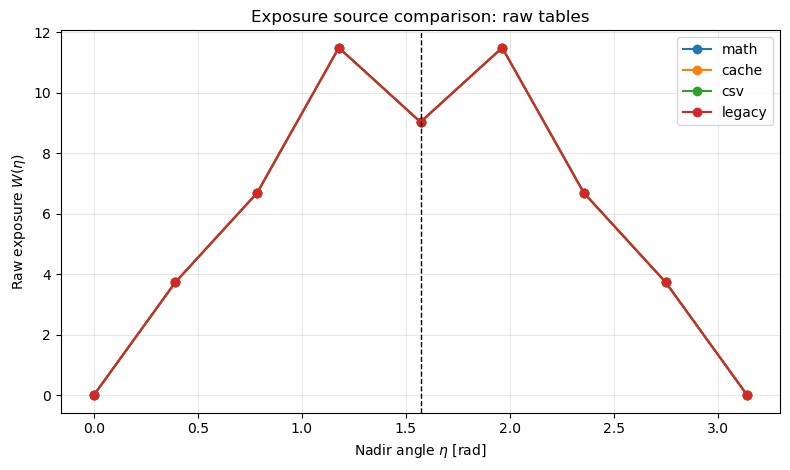

PASSED: plot_raw_source_overlay()


In [9]:
run_notebook_call('plot_raw_source_overlay()', lambda: TEST_MODULE.plot_raw_source_overlay())


## Plot: `plot_difference_from_math()`

**What is checked:** Difference from math behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_exposure_source_difference_from_math.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_difference_from_math()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_exposure_source_difference_from_math.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_difference_from_math() ...
Saved plot: V:\output\test\earth\test4b_exposure_source\plot_difference_from_math_figure_001.png


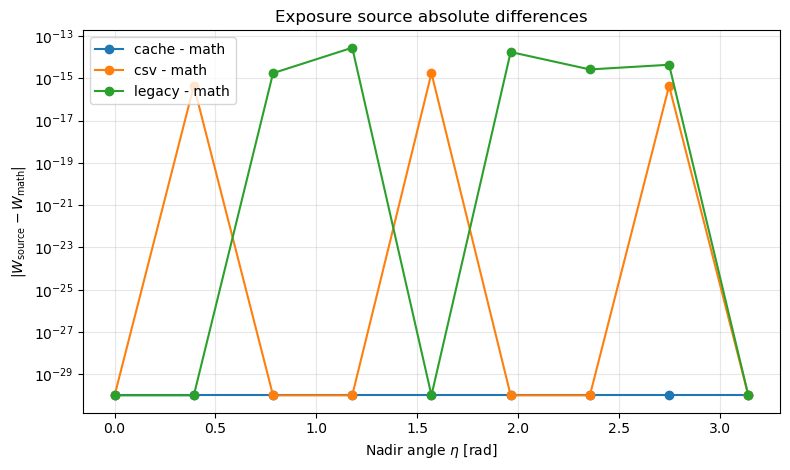

PASSED: plot_difference_from_math()


In [10]:
run_notebook_call('plot_difference_from_math()', lambda: TEST_MODULE.plot_difference_from_math())


## Plot: `plot_normalized_source_overlay()`

**What is checked:** Normalized source overlay behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_exposure_source_normalized_overlay.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; normalization failures often point to probability conservation or broadcasting issues; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_normalized_source_overlay()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_exposure_source_normalized_overlay.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_normalized_source_overlay() ...
Saved plot: V:\output\test\earth\test4b_exposure_source\plot_normalized_source_overlay_figure_001.png


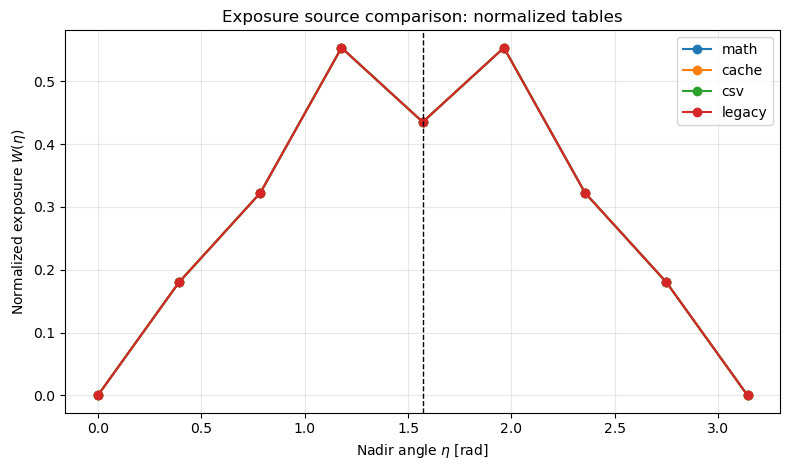

PASSED: plot_normalized_source_overlay()


In [11]:
run_notebook_call('plot_normalized_source_overlay()', lambda: TEST_MODULE.plot_normalized_source_overlay())
